Section 1 — Dataset Overview
The dataset originally contains full-scene images with bounding box annotations, which are converted into cropped images for classification

In [2]:
from pathlib import Path
import csv
import random
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [3]:
PROJECT_ROOT = Path.cwd().parent   # 如果你的 notebook 放在 baseline/ 里面
DATA_ROOT = PROJECT_ROOT / "data"
ANNOTATION_DIR = DATA_ROOT / "BelgiumTSD_annotations"
TRAIN_FILE = ANNOTATION_DIR / "BTSD_training_GTclear.txt"
TEST_FILE = ANNOTATION_DIR / "BTSD_testing_GTclear.txt"

CROPPED_ROOT = Path.cwd() / "cropped_belgiumts_classid"   # baseline/cropped_belgiumts_classid

Section 2 — Before vs After Cropping

In [4]:
# 读取 annotation
def parse_annotation_file(txt_path):
    rows = []
    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        reader = csv.reader(f, delimiter=";")
        for parts in reader:
            parts = [p.strip() for p in parts if p.strip() != ""]
            if len(parts) < 7:
                continue

            img_rel = parts[0]
            x1, y1, x2, y2 = map(float, parts[1:5])
            class_id = int(parts[5])
            superclass_id = int(parts[6])

            rows.append({
                "img_rel": img_rel,
                "camera": img_rel.split("/")[0],
                "image_name": img_rel.split("/")[-1],
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "class_id": class_id,
                "superclass_id": superclass_id,
            })
    return rows

train_rows = parse_annotation_file(TRAIN_FILE)
test_rows = parse_annotation_file(TEST_FILE)

print("Train annotations:", len(train_rows))
print("Test annotations :", len(test_rows))

Train annotations: 8851
Test annotations : 4629


In [5]:
train_df = pd.DataFrame(train_rows)
train_df.head()

,img_rel,camera,image_name,x1,y1,x2,y2,class_id,superclass_id
0,01/image.000935.jp2,01,image.000935.jp2,1346.82,246.76,1582.12,484.41,65,2
1,01/image.000936.jp2,01,image.000936.jp2,1164.88,237.94,1324.29,397.35,65,2
2,01/image.000937.jp2,01,image.000937.jp2,1077.29,232.49,1196.90,352.10,65,2
3,05/image.000938.jp2,05,image.000938.jp2,1346.21,387.23,1427.79,468.53,-1,-1
4,05/image.000939.jp2,05,image.000939.jp2,1466.10,397.68,1566.10,498.02,-1,-1


In [6]:
# 显示已经生成好的 crop 类别分布
train_dir = CROPPED_ROOT / "train"
test_dir = CROPPED_ROOT / "test"

train_class_counts = {}
for cls_dir in sorted(train_dir.iterdir()):
    if cls_dir.is_dir():
        train_class_counts[cls_dir.name] = len(list(cls_dir.glob("*.jpg")))

test_class_counts = {}
for cls_dir in sorted(test_dir.iterdir()):
    if cls_dir.is_dir():
        test_class_counts[cls_dir.name] = len(list(cls_dir.glob("*.jpg")))

print("Train classes:", len(train_class_counts))
print("Test classes :", len(test_class_counts))

Train classes: 47
Test classes : 47


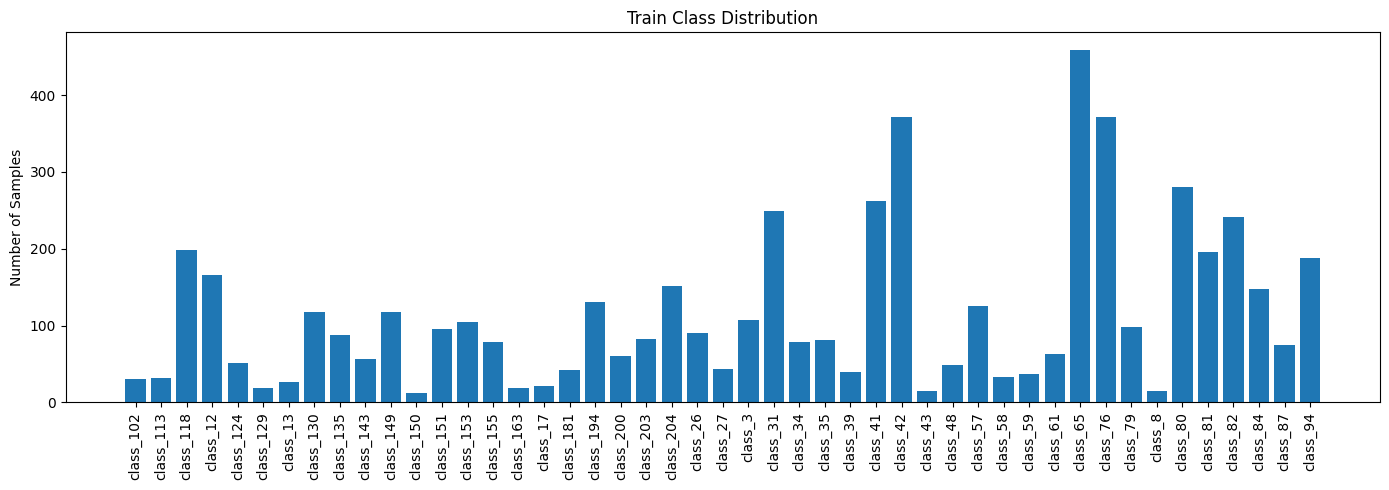

In [7]:
plt.figure(figsize=(14, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.xticks(rotation=90)
plt.title("Train Class Distribution")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

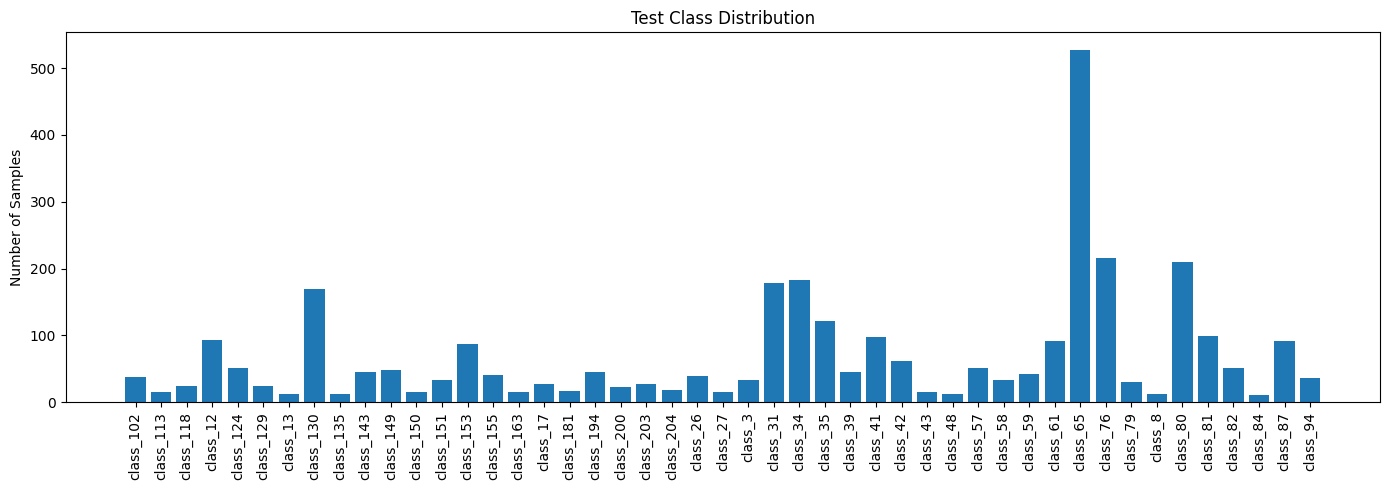

In [8]:
plt.figure(figsize=(14, 5))
plt.bar(test_class_counts.keys(), test_class_counts.values())
plt.xticks(rotation=90)
plt.title("Test Class Distribution")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [9]:
# 每个类别随机显示几张 crop
def show_class_samples(class_name, split="train", num_samples=5):
    class_dir = CROPPED_ROOT / split / class_name
    image_paths = list(class_dir.glob("*.jpg"))

    if len(image_paths) == 0:
        print(f"No images found for {class_name}")
        return

    samples = random.sample(image_paths, min(num_samples, len(image_paths)))

    fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

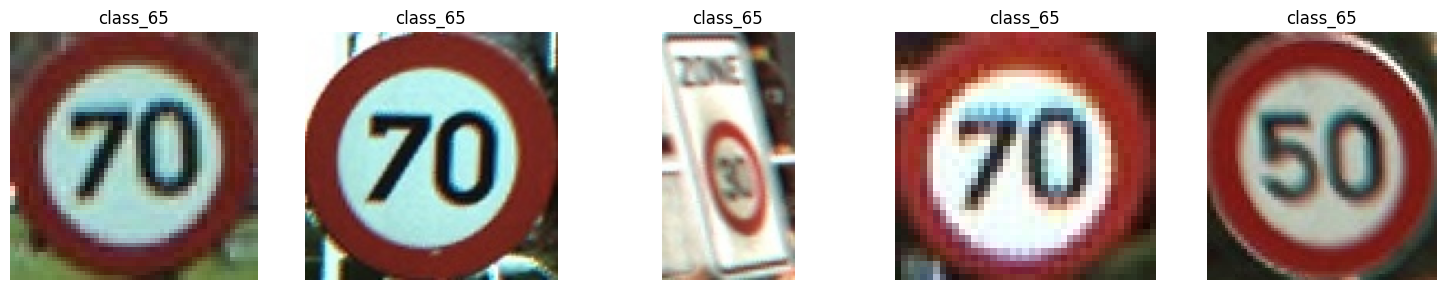

In [10]:
show_class_samples("class_65", split="train", num_samples=5)

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_before_after(row):
    image_path = DATA_ROOT / row["img_rel"]

    img = Image.open(image_path).convert("RGB")

    x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])
    crop = img.crop((x1, y1, x2, y2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ===== 原图 + bbox =====
    axes[0].imshow(img)
    axes[0].add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      fill=False, edgecolor='red', linewidth=2)
    )
    axes[0].set_title(f"Original (class {row['class_id']})")
    axes[0].axis("off")

    # ===== 裁剪图 =====
    axes[1].imshow(crop)
    axes[1].set_title("Cropped Sign")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

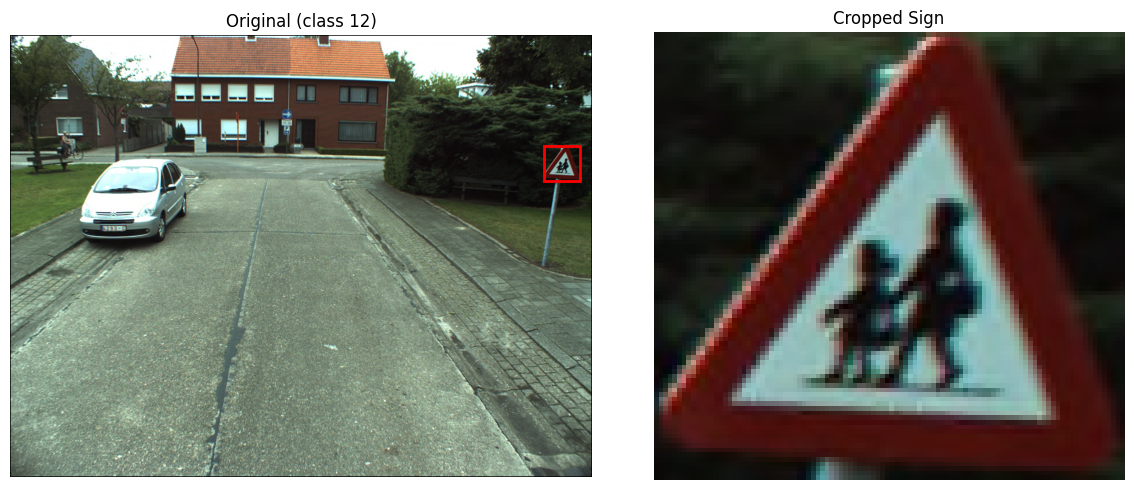

In [12]:
import random

sample = random.choice(train_rows)
show_before_after(sample)

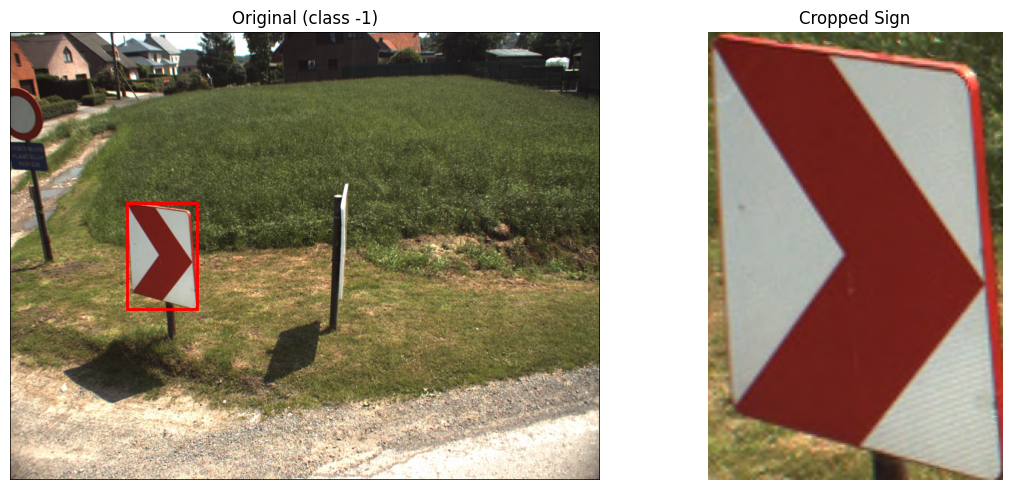

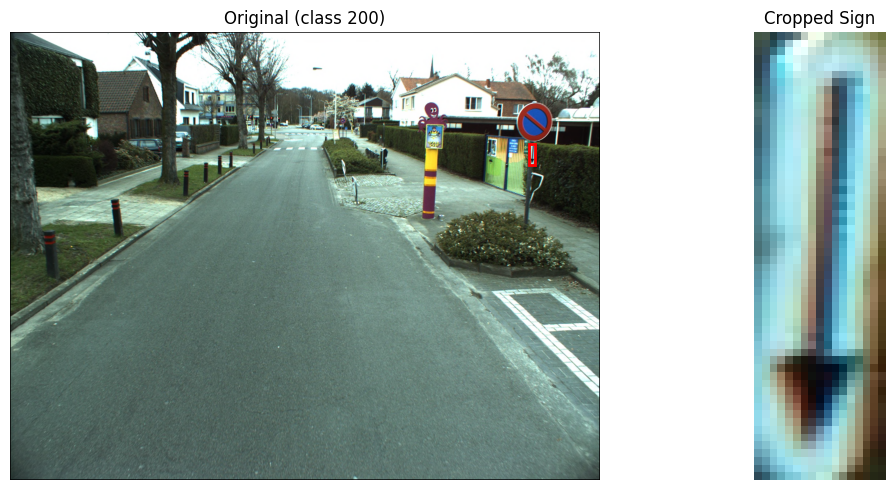

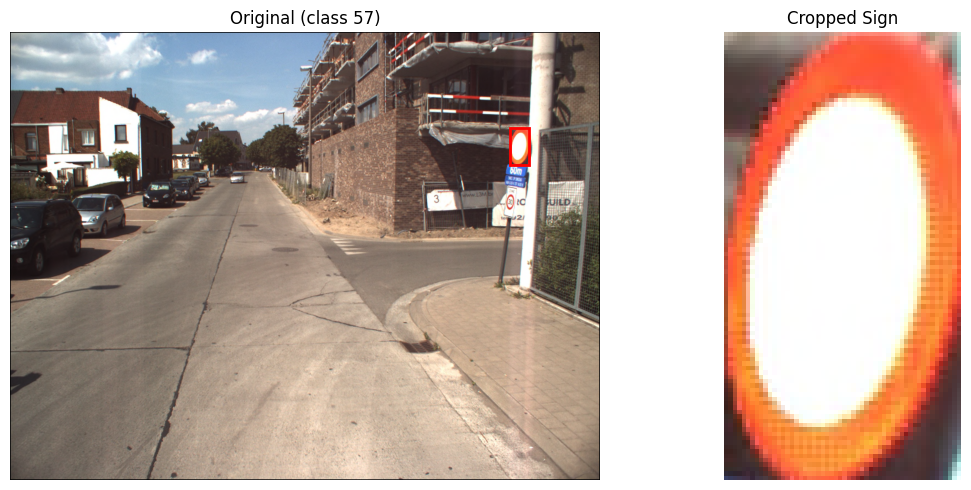

In [13]:
for row in random.sample(train_rows, 3):
    show_before_after(row)

Section 3 — Class Distribution

Section 4 — Sample Images per Class

Section 5 — Data Issues

bbox 有些太小（被过滤）
class imbalance
crop removes context（重要！）

Cropping removes background context, making classification easier but less representative of real-world scenarios.